<div style="background: linear-gradient(135deg, #ff6b6b 0%, #feca57 25%, #48dbfb 50%, #ff9ff3 75%, #54a0ff 100%); padding: 4px; border-radius: 24px; margin-bottom: 6px;">
<div style="background: #1a1a2e; border-radius: 21px; padding: 55px 30px; text-align: center;">
  <p style="color: rgba(255,255,255,0.5); font-size: 0.85em; margin: 0 0 8px; letter-spacing: 5px; text-transform: uppercase;">Python for Data Science</p>
  <h1 style="font-size: 3.4em; font-weight: 900; margin: 0; background: linear-gradient(90deg, #ff6b6b, #feca57, #48dbfb, #ff9ff3); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">Descriptive Statistics</h1>
  <h2 style="color: rgba(255,255,255,0.7); font-size: 1.3em; margin: 10px 0 0; font-weight: 300;">for Beginners</h2>
  <div style="width: 80px; height: 3px; background: linear-gradient(90deg,#ff6b6b,#feca57,#48dbfb); margin: 18px auto;"></div>
  <div style="margin-top: 16px;">
    <span style="background: rgba(255,107,107,0.2); color: #ff6b6b; border: 1px solid #ff6b6b; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; margin: 4px; display: inline-block;">🐍 Python 3</span>
    <span style="background: rgba(254,202,87,0.2); color: #feca57; border: 1px solid #feca57; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; margin: 4px; display: inline-block;">🔢 NumPy</span>
    <span style="background: rgba(72,219,251,0.2); color: #48dbfb; border: 1px solid #48dbfb; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; margin: 4px; display: inline-block;">🐼 Pandas</span>
    <span style="background: rgba(255,159,243,0.2); color: #ff9ff3; border: 1px solid #ff9ff3; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; margin: 4px; display: inline-block;">📊 Matplotlib</span>
    <span style="background: rgba(84,160,255,0.2); color: #54a0ff; border: 1px solid #54a0ff; padding: 5px 16px; border-radius: 20px; font-size: 0.85em; margin: 4px; display: inline-block;">🔰 Beginner Friendly</span>
  </div>
</div>
</div>

## What is Descriptive Statistics?

Imagine you have exam scores for 100 students. You can't read all 100 numbers and understand anything useful. **Descriptive statistics** lets you summarise that entire dataset into a handful of numbers — each one telling a different story.

Think of it like a weather report. Instead of reading every temperature reading of the day, you get: *"High of 35°C, low of 22°C, average 28°C."* That's descriptive statistics.

---

### What You'll Learn

| Measure | Plain English | The Question it Answers |
|---------|--------------|------------------------|
| **Mean** | The average | "What's the typical value?" |
| **Median** | The middle value | "What does a typical person score?" |
| **Mode** | The most common value | "What value appears most?" |
| **Range** | Highest − Lowest | "How wide is the data spread?" |
| **Variance** | Average squared distance from mean | "How far do values stray?" |
| **Std Deviation** | Spread in original units | "How consistent is the data?" |
| **IQR** | Middle 50% range | "What's the spread ignoring outliers?" |
| **Percentiles** | Where a value ranks | "What % of people scored below X?" |

<div style="background: linear-gradient(90deg, rgba(255,107,107,0.15), rgba(254,202,87,0.15)); border-left: 4px solid #feca57; padding: 16px 22px; border-radius: 0 12px 12px 0; margin: 12px 0;">
  <strong style="color: #feca57; font-size: 1.1em;">Setup — Run This First</strong>
  <p style="color: rgba(255,255,255,0.7); margin: 4px 0 0; font-size: 0.9em;">Import libraries and set up the colorful theme.</p>
</div>

In [1]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── Colorful vibrant theme
plt.rcParams.update({
    'figure.facecolor':  '#1a1a2e',
    'axes.facecolor':    '#16213e',
    'axes.edgecolor':    '#0f3460',
    'axes.labelcolor':   '#eaeaea',
    'axes.titlecolor':   'white',
    'xtick.color':       '#aaaaaa',
    'ytick.color':       '#aaaaaa',
    'text.color':        '#eaeaea',
    'grid.color':        '#0f3460',
    'grid.linewidth':    0.8,
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

# ── Vibrant palette
RED    = '#ff6b6b'
YELLOW = '#feca57'
CYAN   = '#48dbfb'
PINK   = '#ff9ff3'
BLUE   = '#54a0ff'
GREEN  = '#1dd1a1'
ORANGE = '#ff9f43'
PURPLE = '#a29bfe'
PALETTE = [RED, YELLOW, CYAN, PINK, BLUE, GREEN, ORANGE, PURPLE]

np.random.seed(42)
print("Ready! Let's explore descriptive statistics.")

Ready! Let's explore descriptive statistics.


<div style="background: linear-gradient(90deg, rgba(72,219,251,0.15), rgba(84,160,255,0.15)); border-left: 4px solid #48dbfb; padding: 16px 22px; border-radius: 0 12px 12px 0; margin: 20px 0;">
  <strong style="color: #48dbfb; font-size: 1.2em;">Our Dataset</strong>
  <p style="color: rgba(255,255,255,0.7); margin: 4px 0 0;">We'll work with a realistic dataset of 60 student exam scores throughout this notebook — the same data across every section so you can see how each measure tells a different story about the same numbers.</p>
</div>

In [2]:
# ============================================================
# THE DATASET — 60 student exam scores
# ============================================================

# A realistic class: most students near 65-75, a few who aced it or failed
core_students  = np.random.normal(68, 11, 50)          # typical students
high_achievers = np.array([92, 95, 97, 98, 100])       # top performers
struggling     = np.array([18, 22, 28, 32, 35])        # who need support

scores = np.concatenate([core_students, high_achievers, struggling])
scores = scores.clip(0, 100).round(1)
np.random.shuffle(scores)   # mix them up — real data isn't sorted!

print(f"Dataset: {len(scores)} student exam scores")
print(f"First 15 values: {scores[:15]}")
print(f"\nRaw data feels overwhelming, right?")
print("That's exactly why we need descriptive statistics!")

Dataset: 60 student exam scores
First 15 values: [ 71.5  58.   66.5  65.4  84.8  88.4 100.   69.2  60.1  70.3  62.9  70.7
  46.4  74.   52.5]

Raw data feels overwhelming, right?
That's exactly why we need descriptive statistics!


<div style="background: linear-gradient(135deg, rgba(255,107,107,0.2), rgba(255,159,67,0.2)); border: 1px solid #ff6b6b; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #ff6b6b; margin: 0 0 8px; font-size: 1.6em;">1. Mean (Average)</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">Add up all values, divide by how many there are.</p>
</div>

**Formula:** &nbsp;&nbsp; $\bar{x} = \dfrac{\sum x_i}{n}$

The mean is the **balancing point** of your data. If you placed all values on a number line and the line was a seesaw, the mean is where it would balance perfectly.

**Weakness:** The mean is sensitive to outliers. One extreme value can pull it far from the "typical" value.

```
Example: Salaries at a small company
5 employees earn: $30k, $32k, $35k, $33k, $34k → mean = $32.8k  ✓ representative
Now the CEO joins: $30k, $32k, $35k, $33k, $34k, $800k → mean = $161k  ✗ misleading!
```

In [3]:
# ============================================================
# MEAN
# ============================================================

# ── Method 1: Manual calculation
mean_manual = sum(scores) / len(scores)

# ── Method 2: NumPy (use this in practice)
mean_numpy = np.mean(scores)

# ── Method 3: Pandas
mean_pandas = pd.Series(scores).mean()

print(f"Mean (manual)  : {mean_manual:.2f}")
print(f"Mean (numpy)   : {mean_numpy:.2f}")
print(f"Mean (pandas)  : {mean_pandas:.2f}")
print("All three give the same answer!")

print()
print("── Outlier sensitivity demo ──")
small_group = np.array([30.0, 32.0, 35.0, 33.0, 34.0])
with_ceo    = np.append(small_group, 800.0)
print(f"Without CEO: mean = ${np.mean(small_group):.1f}k")
print(f"With CEO:    mean = ${np.mean(with_ceo):.1f}k  ← pulled way up!")
print("This is why we also need median.")

# TRY: Change np.mean to np.sum(scores)/len(scores) — same result!

Mean (manual)  : 64.88
Mean (numpy)   : 64.88
Mean (pandas)  : 64.88
All three give the same answer!

── Outlier sensitivity demo ──
Without CEO: mean = $32.8k
With CEO:    mean = $160.7k  ← pulled way up!
This is why we also need median.


<div style="background: linear-gradient(135deg, rgba(254,202,87,0.2), rgba(255,159,67,0.2)); border: 1px solid #feca57; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #feca57; margin: 0 0 8px; font-size: 1.6em;">2. Median</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">The middle value when data is sorted. Half above, half below.</p>
</div>

**How to find it:**
1. Sort all values from smallest to largest
2. If odd count → middle value
3. If even count → average of the two middle values

```
Odd:  [10, 20, 30, 40, 50]  → median = 30  (3rd of 5)
Even: [10, 20, 30, 40]      → median = 25  (average of 20 and 30)
```

**Strength:** The median is **resistant to outliers**. The CEO's $800k salary barely moves it. This makes median better for income, house prices, and any skewed data.

In [4]:
# ============================================================
# MEDIAN
# ============================================================

# ── Manual calculation
sorted_scores = np.sort(scores)
n = len(sorted_scores)

if n % 2 == 1:   # odd count
    median_manual = sorted_scores[n // 2]
else:            # even count
    median_manual = (sorted_scores[n//2 - 1] + sorted_scores[n//2]) / 2

median_numpy = np.median(scores)

print(f"n = {n} (even count)")
print(f"Middle two values: {sorted_scores[n//2-1]} and {sorted_scores[n//2]}")
print(f"Median (manual) : {median_manual:.1f}")
print(f"Median (numpy)  : {median_numpy:.1f}")
print()

mean = np.mean(scores)
print(f"Mean   : {mean:.2f}")
print(f"Median : {median_numpy:.2f}")
diff = mean - median_numpy
print(f"Difference: {diff:.2f} points")
print()
if diff > 2:
    print("Mean > Median → data is RIGHT-SKEWED (outliers on the high end pulling mean up)")
elif diff < -2:
    print("Mean < Median → data is LEFT-SKEWED (outliers on the low end pulling mean down)")
else:
    print("Mean ≈ Median → data is roughly symmetric")

print()
print("── CEO salary demo: median is resistant ──")
salaries_no_ceo = np.array([30.0, 32.0, 35.0, 33.0, 34.0])
salaries_with   = np.append(salaries_no_ceo, 800.0)
print(f"Without CEO: mean={np.mean(salaries_no_ceo):.1f}k  median={np.median(salaries_no_ceo):.1f}k")
print(f"With CEO:    mean={np.mean(salaries_with):.1f}k  median={np.median(salaries_with):.1f}k  ← median barely moved!")

n = 60 (even count)
Middle two values: 65.4 and 65.4
Median (manual) : 65.4
Median (numpy)  : 65.4

Mean   : 64.88
Median : 65.40
Difference: -0.52 points

Mean ≈ Median → data is roughly symmetric

── CEO salary demo: median is resistant ──
Without CEO: mean=32.8k  median=33.0k
With CEO:    mean=160.7k  median=33.5k  ← median barely moved!


<div style="background: linear-gradient(135deg, rgba(72,219,251,0.2), rgba(84,160,255,0.2)); border: 1px solid #48dbfb; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #48dbfb; margin: 0 0 8px; font-size: 1.6em;">3. Mode</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">The value that appears most frequently.</p>
</div>

Mode is the only measure of central tendency that works with **categorical data** too.

```
Shoe sizes sold today: [7, 8, 8, 9, 9, 9, 10, 10]  → mode = 9  (most popular)
Favourite colours: [red, blue, blue, green, blue]   → mode = blue
```

A dataset can have:
- **Unimodal** — one mode (one peak)
- **Bimodal** — two modes (two peaks)
- **Multimodal** — many modes
- **No mode** — all values appear equally

Mode of exam scores : 62.9  (count: 3)
(With continuous data, mode isn't very informative)

Most popular shoe size: 9 (sold 4 times)


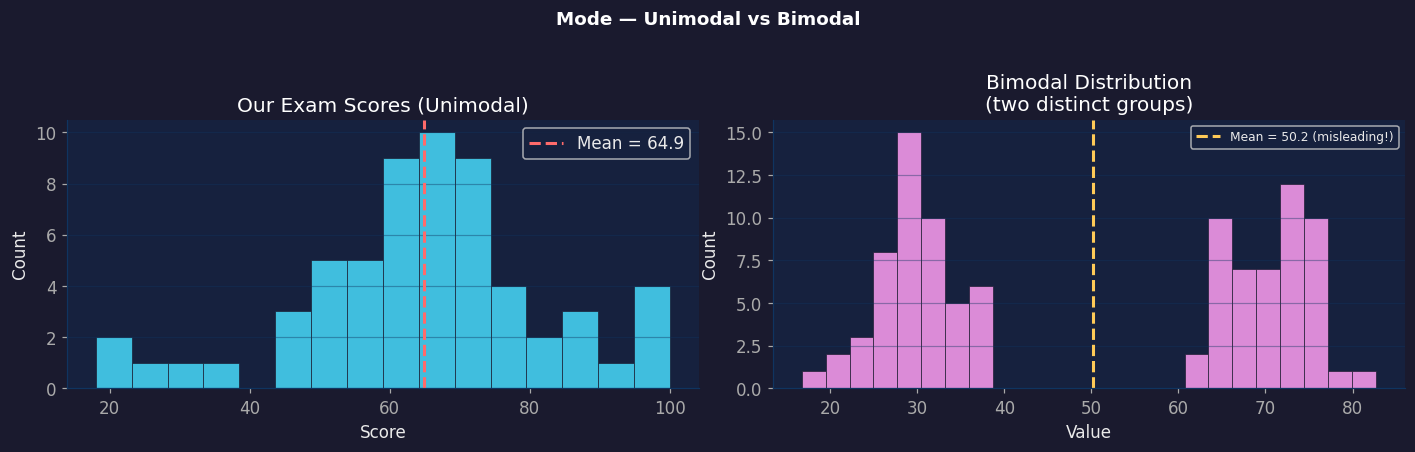

Notice: in a bimodal distribution, the mean falls between the two peaks
and doesn't represent either group well — that's when mode is most useful!


In [5]:
# ============================================================
# MODE
# ============================================================
from scipy.stats import mode as scipy_mode

# Our continuous scores — mode is less meaningful here
result = scipy_mode(scores, keepdims=True)
print(f"Mode of exam scores : {result.mode[0]}  (count: {result.count[0]})")
print("(With continuous data, mode isn't very informative)")
print()

# ── Mode shines with discrete / categorical data
shoe_sizes = np.array([6, 7, 7, 8, 8, 8, 9, 9, 9, 9, 10, 10, 11])
shoe_mode = scipy_mode(shoe_sizes, keepdims=True)
print(f"Most popular shoe size: {shoe_mode.mode[0]} (sold {shoe_mode.count[0]} times)")

# ── Detecting bimodal distribution
bimodal = np.concatenate([
    np.random.normal(30, 5, 50),   # group 1 peaks at 30
    np.random.normal(70, 5, 50),   # group 2 peaks at 70
])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Mode — Unimodal vs Bimodal', fontsize=12,
             fontweight='bold', color='white', y=1.02)

# Unimodal
axes[0].hist(scores, bins=16, color=CYAN, alpha=0.85,
             edgecolor='#1a1a2e', linewidth=0.5)
axes[0].axvline(np.mean(scores), color=RED, lw=2, linestyle='--',
                label=f'Mean = {np.mean(scores):.1f}')
axes[0].set_title('Our Exam Scores (Unimodal)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)

# Bimodal
axes[1].hist(bimodal, bins=24, color=PINK, alpha=0.85,
             edgecolor='#1a1a2e', linewidth=0.5)
axes[1].axvline(np.mean(bimodal), color=YELLOW, lw=2, linestyle='--',
                label=f'Mean = {np.mean(bimodal):.1f} (misleading!)')
axes[1].set_title('Bimodal Distribution\n(two distinct groups)')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()
print("Notice: in a bimodal distribution, the mean falls between the two peaks")
print("and doesn't represent either group well — that's when mode is most useful!")

<div style="background: linear-gradient(135deg, rgba(29,209,161,0.2), rgba(72,219,251,0.2)); border: 1px solid #1dd1a1; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #1dd1a1; margin: 0 0 8px; font-size: 1.6em;">4. Measures of Spread</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">Range, Variance, Standard Deviation, and IQR</p>
</div>

Central tendency (mean/median/mode) tells you *where* the data is centred. **Spread** tells you *how wide* it is.

Two classes can have the same average but be totally different:
```
Class A scores: [68, 69, 70, 71, 72]  → mean = 70, std = 1.4  (very consistent)
Class B scores: [20, 50, 70, 90, 100] → mean = 70, std = 29.4 (wildly spread)
```

| Measure | Formula | Intuition |
|---------|---------|----------|
| **Range** | max − min | Total span of data |
| **Variance** | avg of (xi − x̄)² | Average squared distance from mean |
| **Std Dev** | √variance | Same as variance but in original units |
| **IQR** | Q3 − Q1 | Range of the middle 50% (outlier-resistant) |

In [6]:
# ============================================================
# MEASURES OF SPREAD
# ============================================================

# ── Range
data_range = scores.max() - scores.min()

# ── Variance (ddof=1 for sample variance — use this unless you have ALL data)
variance = np.var(scores, ddof=1)

# ── Standard Deviation
std_dev = np.std(scores, ddof=1)   # = sqrt(variance)

# ── Quartiles and IQR
q1  = np.percentile(scores, 25)
q2  = np.percentile(scores, 50)   # same as median
q3  = np.percentile(scores, 75)
iqr = q3 - q1

mean = np.mean(scores)

print("─" * 44)
print("     SPREAD MEASURES — EXAM SCORES")
print("─" * 44)
print(f"  Min            :  {scores.min():.1f}")
print(f"  Max            :  {scores.max():.1f}")
print(f"  Range          :  {data_range:.1f}")
print(f"  Variance       :  {variance:.2f}  (units: score²)")
print(f"  Std Deviation  :  {std_dev:.2f}  (units: score)")
print(f"  Q1 (25th pct)  :  {q1:.1f}")
print(f"  Q2 (median)    :  {q2:.1f}")
print(f"  Q3 (75th pct)  :  {q3:.1f}")
print(f"  IQR            :  {iqr:.1f}")
print("─" * 44)
print(f"\n68% of scores likely fall between:")
print(f"  {mean-std_dev:.1f}  and  {mean+std_dev:.1f}  (mean ± 1σ)")
print(f"95% of scores likely fall between:")
print(f"  {mean-2*std_dev:.1f}  and  {mean+2*std_dev:.1f}  (mean ± 2σ)")

────────────────────────────────────────────
     SPREAD MEASURES — EXAM SCORES
────────────────────────────────────────────
  Min            :  18.0
  Max            :  100.0
  Range          :  82.0
  Variance       :  297.74  (units: score²)
  Std Deviation  :  17.26  (units: score)
  Q1 (25th pct)  :  56.1
  Q2 (median)    :  65.4
  Q3 (75th pct)  :  73.6
  IQR            :  17.5
────────────────────────────────────────────

68% of scores likely fall between:
  47.6  and  82.1  (mean ± 1σ)
95% of scores likely fall between:
  30.4  and  99.4  (mean ± 2σ)


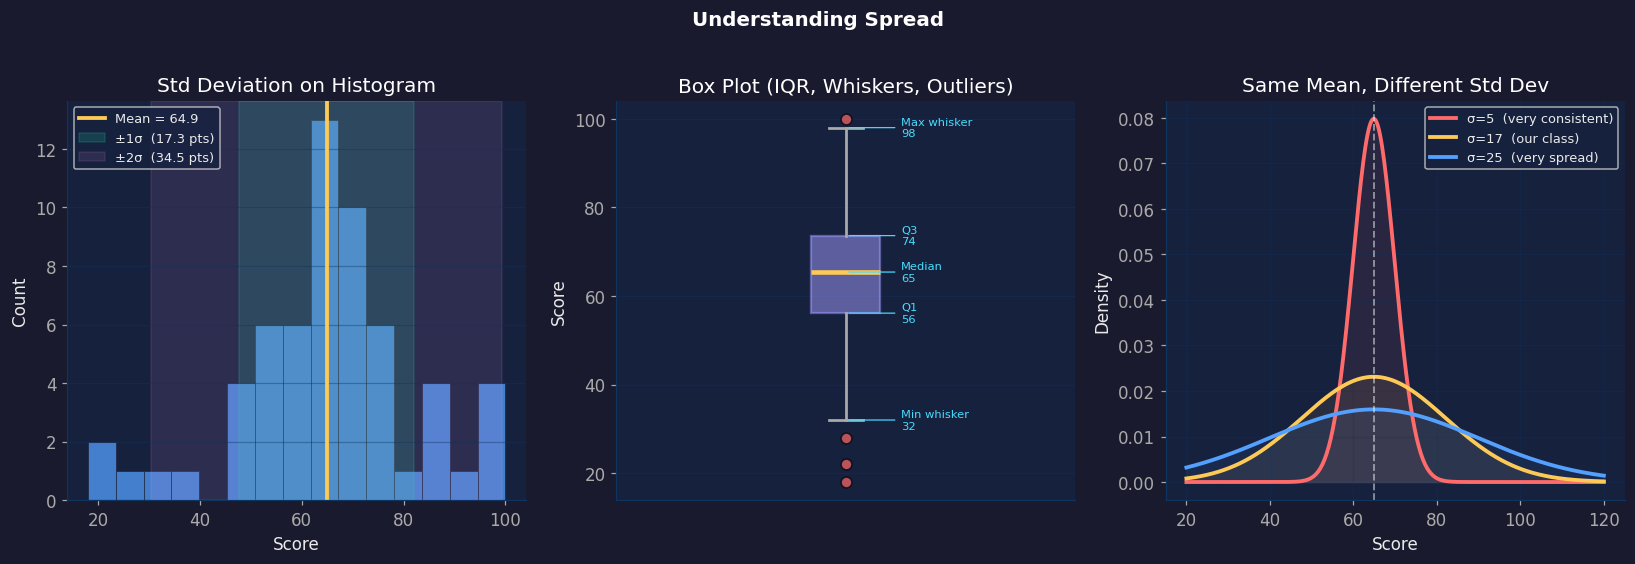

In [7]:
# ============================================================
# SPREAD — Visualised
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Understanding Spread', fontsize=13,
             fontweight='bold', color='white', y=1.02)

mean = np.mean(scores)

# ── 1. Standard deviation visualised on histogram
ax = axes[0]
ax.hist(scores, bins=15, color=BLUE, alpha=0.75,
        edgecolor='#1a1a2e', linewidth=0.5)
ax.axvline(mean,          color=YELLOW, lw=2.5, label=f'Mean = {mean:.1f}')
ax.axvspan(mean-std_dev, mean+std_dev, alpha=0.18, color=GREEN,
           label=f'±1σ  ({std_dev:.1f} pts)')
ax.axvspan(mean-2*std_dev, mean+2*std_dev, alpha=0.10, color=PINK,
           label=f'±2σ  ({2*std_dev:.1f} pts)')
ax.set_title('Std Deviation on Histogram')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
ax.legend(fontsize=8.5); ax.grid(axis='y', alpha=0.4)

# ── 2. Box plot — the IQR diagram
ax = axes[1]
bp = ax.boxplot(scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PURPLE, alpha=0.5, linewidth=1.5,
                              edgecolor=PURPLE),
                medianprops=dict(color=YELLOW, linewidth=3),
                whiskerprops=dict(color='#aaaaaa', linewidth=1.8),
                capprops=dict(color='#aaaaaa', linewidth=1.8),
                flierprops=dict(marker='o', color=RED, markersize=7,
                                alpha=0.7, markerfacecolor=RED))
ax.set_title('Box Plot (IQR, Whiskers, Outliers)')
ax.set_ylabel('Score')
ax.set_xticks([])
# Annotations
for label, val, xoff in [('Min whisker', scores[scores >= q1-1.5*iqr].min(), 14),
                          ('Q1', q1, 14), ('Median', q2, 14),
                          ('Q3', q3, 14), ('Max whisker', scores[scores <= q3+1.5*iqr].max(), 14)]:
    ax.annotate(f'{label}\n{val:.0f}', xy=(1, val),
                xytext=(1.12, val), color=CYAN, fontsize=7.5,
                va='center',
                arrowprops=dict(arrowstyle='-', color=CYAN, lw=0.8))
ax.grid(axis='y', alpha=0.4)

# ── 3. Std dev comparison — same mean, different spread
ax = axes[2]
x = np.linspace(20, 120, 400)
configs = [
    (mean, 5,        RED,    'σ=5  (very consistent)'),
    (mean, std_dev,  YELLOW, f'σ={std_dev:.0f}  (our class)'),
    (mean, 25,       BLUE,   'σ=25  (very spread)'),
]
from scipy.stats import norm
for mu, sigma, col, label in configs:
    y = norm.pdf(x, mu, sigma)
    ax.plot(x, y, color=col, linewidth=2.5, label=label)
    ax.fill_between(x, y, alpha=0.08, color=col)
ax.axvline(mean, color='white', lw=1.2, linestyle='--', alpha=0.5)
ax.set_title('Same Mean, Different Std Dev')
ax.set_xlabel('Score'); ax.set_ylabel('Density')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# TRY: Change ddof=1 to ddof=0 — this gives population variance instead of sample

<div style="background: linear-gradient(135deg, rgba(255,159,243,0.2), rgba(162,155,254,0.2)); border: 1px solid #ff9ff3; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #ff9ff3; margin: 0 0 8px; font-size: 1.6em;">5. Percentiles &amp; Quartiles</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">Where does a value rank relative to the rest?</p>
</div>

The **pth percentile** is the value below which p% of the data falls.

```
You scored at the 85th percentile → you scored higher than 85% of students

Q1 = 25th percentile  (bottom 25% of data)
Q2 = 50th percentile  (= median)
Q3 = 75th percentile  (top 25% starts here)
```

**Why IQR over Range?** The range uses just two values (min and max) which are the most likely to be outliers. The IQR uses the middle 50% and is therefore much more robust.

In [8]:
# ============================================================
# PERCENTILES
# ============================================================

# Common percentiles
pcts = [10, 25, 50, 75, 90, 95, 99]
values = np.percentile(scores, pcts)

print("Percentile table for exam scores:")
print("─" * 35)
for p, v in zip(pcts, values):
    bar = '█' * int(v / 5)
    print(f"  {p:3d}th pct : {v:5.1f}  {bar}")
print()

# Practical use: grade cutoffs
print("── Grade Cutoffs (percentile-based) ──")
cutoffs = {'A (top 10%)': 90, 'B (top 25%)': 75,
           'C (top 50%)': 50, 'D (top 75%)': 25}
for grade, pct in cutoffs.items():
    cutoff = np.percentile(scores, pct)
    print(f"  {grade}: score >= {cutoff:.1f}")

print()
# Where does a specific score rank?
my_score = 78.0
percentile_rank = stats.percentileofscore(scores, my_score)
print(f"── If you scored {my_score}: ──")
print(f"  You're at the {percentile_rank:.1f}th percentile")
print(f"  You scored higher than {percentile_rank:.1f}% of students")

# TRY: Change my_score to your own score and see your percentile rank!

Percentile table for exam scores:
───────────────────────────────────
   10th pct :  46.9  █████████
   25th pct :  56.1  ███████████
   50th pct :  65.4  █████████████
   75th pct :  73.6  ██████████████
   90th pct :  85.7  █████████████████
   95th pct :  95.1  ███████████████████
   99th pct :  98.8  ███████████████████

── Grade Cutoffs (percentile-based) ──
  A (top 10%): score >= 85.7
  B (top 25%): score >= 73.6
  C (top 50%): score >= 65.4
  D (top 75%): score >= 56.1

── If you scored 78.0: ──
  You're at the 83.3th percentile
  You scored higher than 83.3% of students


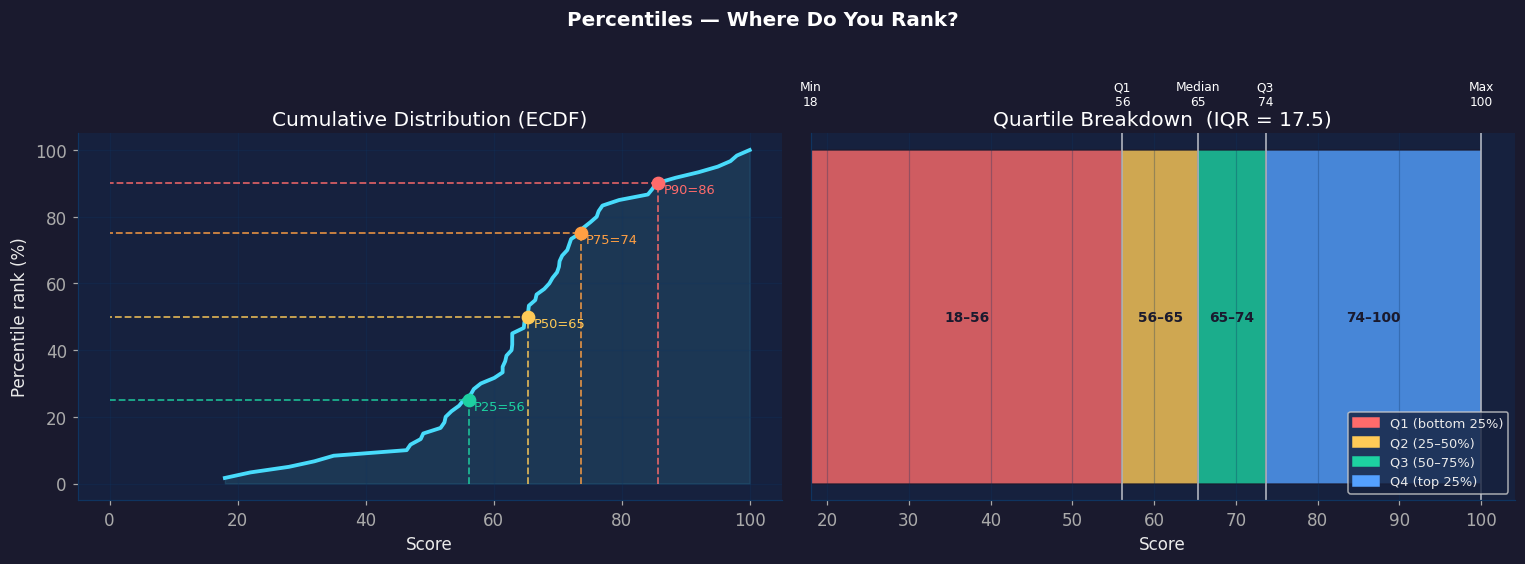

In [9]:
# ============================================================
# PERCENTILE VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Percentiles — Where Do You Rank?', fontsize=13,
             fontweight='bold', color='white', y=1.02)

# ── 1. Cumulative distribution (ECDF)
ax = axes[0]
sorted_s = np.sort(scores)
ecdf_y   = np.arange(1, len(sorted_s)+1) / len(sorted_s) * 100
ax.plot(sorted_s, ecdf_y, color=CYAN, linewidth=2.5)
ax.fill_between(sorted_s, ecdf_y, alpha=0.12, color=CYAN)

# Mark key percentiles
for p, col in [(25, GREEN), (50, YELLOW), (75, ORANGE), (90, RED)]:
    v = np.percentile(scores, p)
    ax.plot([v, v, 0], [0, p, p], color=col, lw=1.2,
            linestyle='--', alpha=0.8)
    ax.plot(v, p, 'o', color=col, markersize=8)
    ax.text(v+0.8, p-3, f'P{p}={v:.0f}', color=col, fontsize=8.5)

ax.set_xlabel('Score')
ax.set_ylabel('Percentile rank (%)')
ax.set_title('Cumulative Distribution (ECDF)')
ax.grid(alpha=0.3)

# ── 2. Colourful quartile breakdown
ax = axes[1]
q0, q1, q2, q3, q4 = scores.min(), *np.percentile(scores,[25,50,75]), scores.max()
quarters = [
    (q0, q1, RED,    'Q1 (bottom 25%)'),
    (q1, q2, YELLOW, 'Q2 (25–50%)'),
    (q2, q3, GREEN,  'Q3 (50–75%)'),
    (q3, q4, BLUE,   'Q4 (top 25%)'),
]
y_pos, height = 0.3, 0.4
for lo, hi, col, label in quarters:
    ax.barh(y_pos, hi-lo, left=lo, height=height,
            color=col, alpha=0.8, edgecolor='#1a1a2e')
    mid = lo + (hi-lo)/2
    ax.text(mid, y_pos, f'{lo:.0f}–{hi:.0f}', ha='center', va='center',
            color='#1a1a2e', fontweight='bold', fontsize=9)

for val, name in [(q0,'Min'),(q1,'Q1'),(q2,'Median'),(q3,'Q3'),(q4,'Max')]:
    ax.axvline(val, color='white', lw=1.2, alpha=0.6)
    ax.text(val, y_pos+0.25, f'{name}\n{val:.0f}',
            ha='center', va='bottom', color='white', fontsize=8)

handles = [mpatches.Patch(color=c, label=l) for _,_,c,l in quarters]
ax.legend(handles=handles, loc='lower right', fontsize=8.5)
ax.set_xlabel('Score')
ax.set_title(f'Quartile Breakdown  (IQR = {iqr:.1f})')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, rgba(255,159,67,0.2), rgba(255,107,107,0.2)); border: 1px solid #ff9f43; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #ff9f43; margin: 0 0 8px; font-size: 1.6em;">6. Shape — Skewness &amp; Kurtosis</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">The 'personality' of a distribution</p>
</div>

Beyond just the centre and spread, a distribution has a **shape**.

**Skewness** measures asymmetry:
```
Skewness ≈ 0   → symmetric  (mean ≈ median)
Skewness > 0   → right-skewed (long tail to the right, mean > median)
Skewness < 0   → left-skewed  (long tail to the left,  mean < median)
```

**Real-world examples:**
- Income distribution → right-skewed (most people earn little, a few earn millions)
- Age at retirement → left-skewed (most retire late, few retire very early)
- Heights → roughly symmetric

Skewness : -0.400
  → Roughly symmetric

Kurtosis : 0.773
  → Mesokurtic: roughly normal peak shape


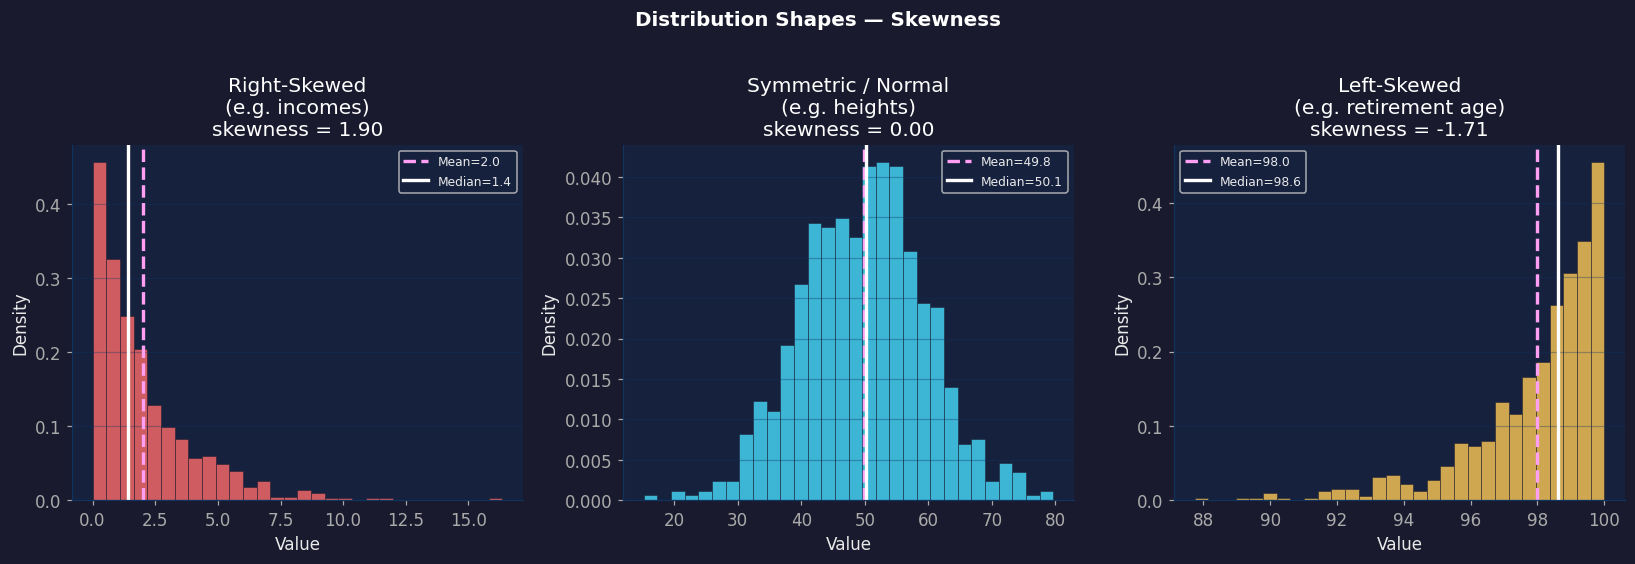

Notice: in right-skewed data, mean > median (pulled right by large outliers).
In left-skewed data, mean < median (pulled left by small outliers).


In [10]:
# ============================================================
# SKEWNESS & SHAPE
# ============================================================

skewness = pd.Series(scores).skew()
kurt     = pd.Series(scores).kurtosis()

print(f"Skewness : {skewness:.3f}")
if   skewness >  0.5: print("  → Notably RIGHT-skewed (tail on right, mean > median)")
elif skewness < -0.5: print("  → Notably LEFT-skewed  (tail on left,  mean < median)")
else:                 print("  → Roughly symmetric")

print(f"\nKurtosis : {kurt:.3f}")
if   kurt > 1:  print("  → Leptokurtic: sharp peak, heavy tails (more outliers than normal)")
elif kurt < -1: print("  → Platykurtic: flat peak, light tails (fewer outliers than normal)")
else:           print("  → Mesokurtic: roughly normal peak shape")

# ── Visual comparison of three shapes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution Shapes — Skewness', fontsize=13,
             fontweight='bold', color='white', y=1.02)

datasets = [
    (np.random.exponential(2, 800),                         'Right-Skewed\n(e.g. incomes)',     RED),
    (np.random.normal(50, 10, 800),                         'Symmetric / Normal\n(e.g. heights)',CYAN),
    (100 - np.random.exponential(2, 800),                   'Left-Skewed\n(e.g. retirement age)',YELLOW),
]
for ax, (data, title, col) in zip(axes, datasets):
    data = np.clip(data, data.min(), data.max())
    m, med = np.mean(data), np.median(data)
    sk = pd.Series(data).skew()
    ax.hist(data, bins=30, color=col, alpha=0.8,
            edgecolor='#1a1a2e', linewidth=0.4, density=True)
    ax.axvline(m,   color=PINK,   lw=2.2, linestyle='--', label=f'Mean={m:.1f}')
    ax.axvline(med, color='white', lw=2.2, linestyle='-',  label=f'Median={med:.1f}')
    ax.set_title(f'{title}\nskewness = {sk:.2f}')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.show()
print("Notice: in right-skewed data, mean > median (pulled right by large outliers).")
print("In left-skewed data, mean < median (pulled left by small outliers).")

<div style="background: linear-gradient(135deg, rgba(84,160,255,0.2), rgba(162,155,254,0.2)); border: 1px solid #54a0ff; padding: 22px 26px; border-radius: 16px; margin: 20px 0;">
  <h2 style="color: #54a0ff; margin: 0 0 8px; font-size: 1.6em;">7. Everything Together — Real Dataset</h2>
  <p style="color: rgba(255,255,255,0.8); margin: 0; font-size: 1em;">The full descriptive stats workflow on a multi-column Pandas DataFrame</p>
</div>

── Pandas .describe() — one line does everything ──
         math  science  english  history
count  100.00   100.00   100.00   100.00
mean    68.17    71.25    74.94    62.62
std     14.33    10.61     8.06    16.64
min     36.00    49.40    54.30    15.70
25%     60.45    63.10    70.30    52.10
50%     67.05    72.60    74.75    63.55
75%     76.60    78.55    80.88    72.95
max     99.60    94.70    91.50   100.00

── Additional shape measures ──
         skewness  kurtosis
math        0.048    -0.306
science    -0.080    -0.618
english    -0.280    -0.202
history    -0.055     0.013


/tmp/ipykernel_17/4250745443.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[s] for s in subjects], patch_artist=True,


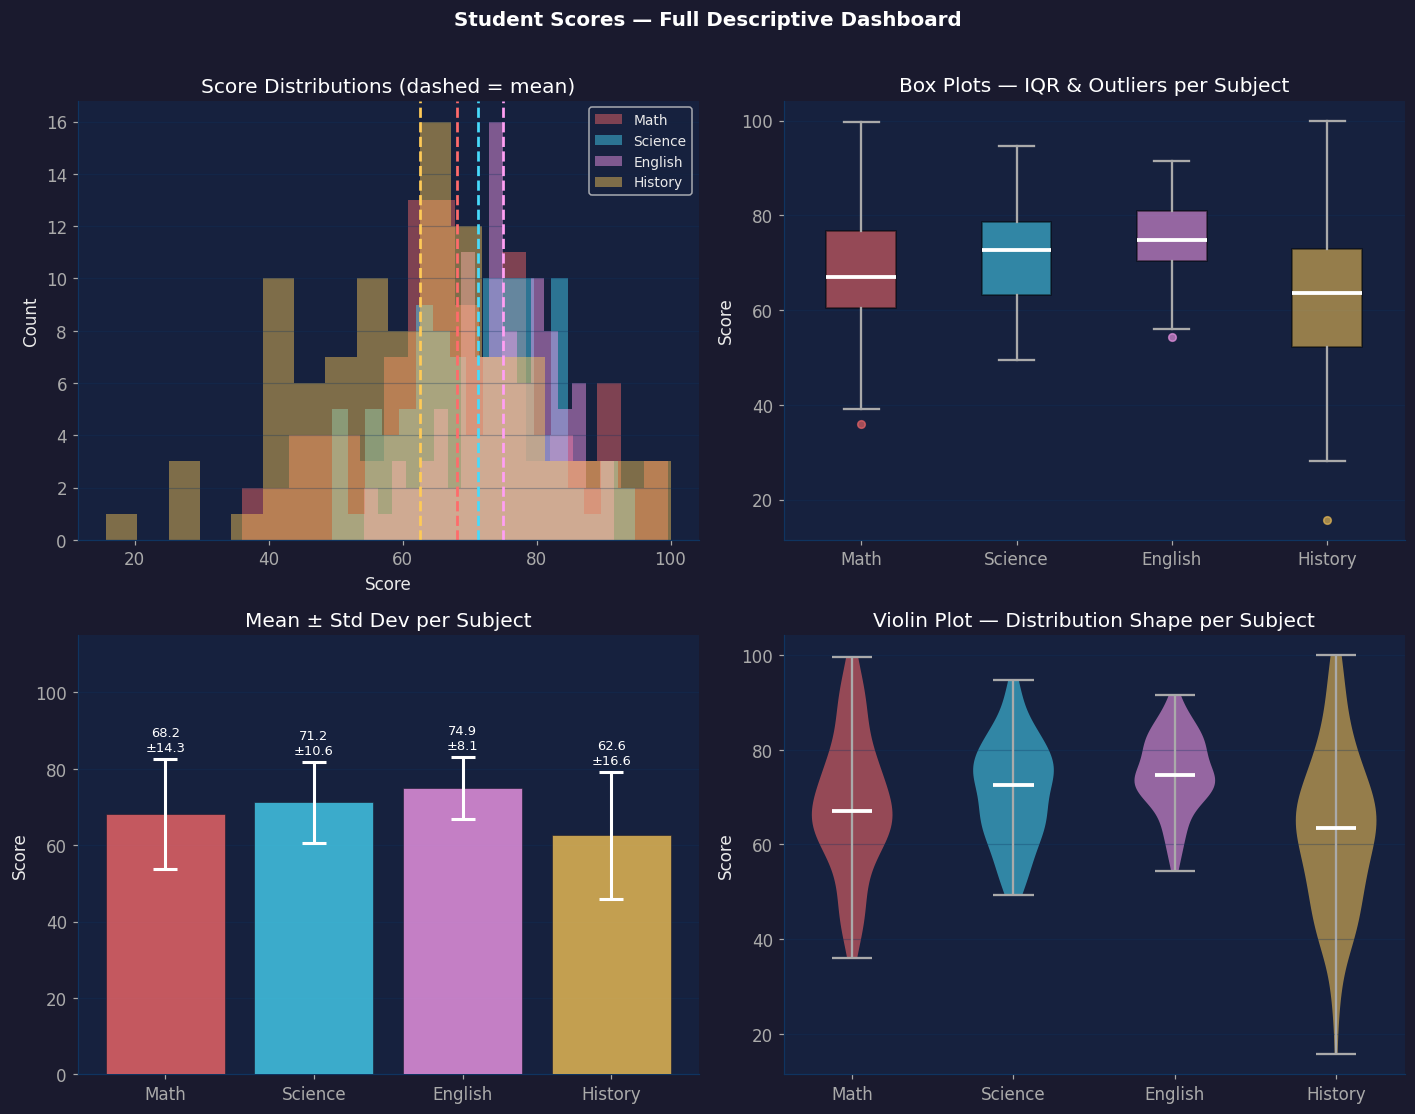

In [11]:
# ============================================================
# FULL WORKFLOW — multi-subject student dataset
# ============================================================

np.random.seed(7)
n = 100
df = pd.DataFrame({
    'math':    np.random.normal(68, 14, n).clip(0, 100).round(1),
    'science': np.random.normal(72, 11, n).clip(0, 100).round(1),
    'english': np.random.normal(75,  9, n).clip(0, 100).round(1),
    'history': np.random.normal(65, 16, n).clip(0, 100).round(1),
})

print("── Pandas .describe() — one line does everything ──")
print(df.describe().round(2))
print()
print("── Additional shape measures ──")
print(pd.DataFrame({'skewness': df.skew().round(3),
                    'kurtosis': df.kurtosis().round(3)}))

# ── Big summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Student Scores — Full Descriptive Dashboard',
             fontsize=13, fontweight='bold', color='white', y=1.01)

subjects = df.columns.tolist()
colors   = [RED, CYAN, PINK, YELLOW]

# ── Overlapping histograms
ax = axes[0][0]
for subj, col in zip(subjects, colors):
    ax.hist(df[subj], bins=18, color=col, alpha=0.45,
            edgecolor='none', label=subj.title())
    ax.axvline(df[subj].mean(), color=col, lw=1.8, linestyle='--')
ax.set_title('Score Distributions (dashed = mean)')
ax.set_xlabel('Score'); ax.set_ylabel('Count')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Box plots side by side
ax = axes[0][1]
bp = ax.boxplot([df[s] for s in subjects], patch_artist=True,
                labels=[s.title() for s in subjects],
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color='#aaaaaa', linewidth=1.5),
                capprops=dict(color='#aaaaaa', linewidth=1.5),
                flierprops=dict(marker='o', markersize=5, alpha=0.6))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.55)
for flier, col in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(col)
    flier.set_markeredgecolor(col)
ax.set_title('Box Plots — IQR & Outliers per Subject')
ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)

# ── Mean ± std dev comparison bar chart
ax = axes[1][0]
means = df.mean()
stds  = df.std()
x     = np.arange(len(subjects))
bars  = ax.bar(x, means, color=colors, alpha=0.75,
               edgecolor='#1a1a2e', linewidth=0.5, zorder=3)
ax.errorbar(x, means, yerr=stds, fmt='none',
            color='white', capsize=8, linewidth=2, capthick=2, zorder=4)
ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in subjects])
ax.set_ylabel('Score')
ax.set_title('Mean ± Std Dev per Subject')
ax.set_ylim(0, 115)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m+s+2, f'{m:.1f}\n±{s:.1f}', ha='center',
            color='white', fontsize=8.5)
ax.grid(axis='y', alpha=0.3, zorder=0)

# ── Violin plot (distribution shape + IQR in one)
ax = axes[1][1]
parts = ax.violinplot([df[s] for s in subjects],
                      positions=range(len(subjects)),
                      showmedians=True, showextrema=True)
for i, (pc, col) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(col)
    pc.set_alpha(0.55)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2.5)
parts['cbars'].set_color('#aaaaaa')
parts['cmins'].set_color('#aaaaaa')
parts['cmaxes'].set_color('#aaaaaa')
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels([s.title() for s in subjects])
ax.set_title('Violin Plot — Distribution Shape per Subject')
ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background: #1a1a2e; padding: 30px; border-radius: 18px; border: 2px solid; border-image: linear-gradient(135deg, #ff6b6b, #feca57, #48dbfb, #ff9ff3) 1; margin: 24px 0;">
  <h2 style="background: linear-gradient(90deg,#ff6b6b,#feca57,#48dbfb,#ff9ff3); -webkit-background-clip:text; -webkit-text-fill-color:transparent; background-clip:text; margin-top:0; text-align:center; font-size:1.9em;">Descriptive Stats Cheat Sheet</h2>
  <table style="width:100%;border-collapse:collapse;font-size:0.93em;">
    <thead>
      <tr style="background:linear-gradient(90deg,#ff6b6b,#feca57);">
        <th style="padding:11px 14px;text-align:left;color:#1a1a2e;">Measure</th>
        <th style="padding:11px 14px;text-align:left;color:#1a1a2e;">NumPy / Pandas</th>
        <th style="padding:11px 14px;text-align:left;color:#1a1a2e;">Use when</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#16213e;"><td style="padding:9px 14px;color:#ff6b6b;font-weight:700;border-bottom:1px solid #0f3460;">Mean</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">np.mean(data)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Symmetric data, no extreme outliers</td></tr>
      <tr style="background:#1a1a2e;"><td style="padding:9px 14px;color:#feca57;font-weight:700;border-bottom:1px solid #0f3460;">Median</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">np.median(data)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Skewed data, income, house prices</td></tr>
      <tr style="background:#16213e;"><td style="padding:9px 14px;color:#48dbfb;font-weight:700;border-bottom:1px solid #0f3460;">Mode</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">scipy.stats.mode(data)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Categorical data, shoe sizes, votes</td></tr>
      <tr style="background:#1a1a2e;"><td style="padding:9px 14px;color:#1dd1a1;font-weight:700;border-bottom:1px solid #0f3460;">Std Dev</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">np.std(data, ddof=1)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Measuring spread in original units</td></tr>
      <tr style="background:#16213e;"><td style="padding:9px 14px;color:#ff9ff3;font-weight:700;border-bottom:1px solid #0f3460;">IQR</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">np.percentile(d,75) - np.percentile(d,25)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Spread without outlier influence</td></tr>
      <tr style="background:#1a1a2e;"><td style="padding:9px 14px;color:#a29bfe;font-weight:700;border-bottom:1px solid #0f3460;">Percentile</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">np.percentile(data, p)</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Ranking a value against others</td></tr>
      <tr style="background:#16213e;"><td style="padding:9px 14px;color:#ff9f43;font-weight:700;border-bottom:1px solid #0f3460;">Skewness</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;border-bottom:1px solid #0f3460;">pd.Series(data).skew()</td><td style="padding:9px 14px;color:#aaaaaa;border-bottom:1px solid #0f3460;">Checking if distribution is asymmetric</td></tr>
      <tr style="background:#1a1a2e;"><td style="padding:9px 14px;color:#54a0ff;font-weight:700;">Full summary</td><td style="padding:9px 14px;font-family:monospace;color:#48dbfb;">df.describe()</td><td style="padding:9px 14px;color:#aaaaaa;">First step on any new dataset</td></tr>
    </tbody>
  </table>
</div>

## What's Next?

You now know how to fully describe any dataset! Here's where to go from here:

| Next Topic | What you'll learn |
|------------|------------------|
| **Distributions** | Why data takes different shapes — normal, skewed, binomial |
| **Hypothesis Testing** | Is a difference in means real, or just random chance? |
| **Correlation** | How strongly do two variables move together? |
| **Regression** | Predict one variable from another |

### Practice Challenges
1. Load the **Titanic dataset** and run `.describe()` on `Age` and `Fare`
2. **Compare** mean vs median of `Fare` — which is more representative? Why?
3. Find the **IQR** of `Age` and identify outliers using the 1.5×IQR rule
4. Plot a **violin plot** comparing `Fare` for survivors vs non-survivors

---

<div style="background: linear-gradient(135deg, #ff6b6b 0%, #feca57 25%, #48dbfb 50%, #ff9ff3 75%, #54a0ff 100%); padding: 3px; border-radius: 18px;">
<div style="background: #1a1a2e; border-radius: 16px; padding: 28px; text-align: center;">
  <h3 style="background:linear-gradient(90deg,#ff6b6b,#feca57,#48dbfb); -webkit-background-clip:text; -webkit-text-fill-color:transparent; background-clip:text; margin:0 0 10px; font-size:1.5em;">You can now describe any dataset!</h3>
  <p style="color:rgba(255,255,255,0.7);margin:0;">Mean, median, mode, std dev, IQR, percentiles, skewness — you've got them all.</p>
  <p style="color:rgba(255,255,255,0.35);margin:10px 0 0;font-size:0.9em;">Happy coding! 🐍📊✨</p>
</div>
</div>